In [94]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [95]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [96]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
#df

In [97]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != [500, 150]') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')
matpes_nofe8b4_freeze = df.query('id == "matpes_nofe8b4_freeze"')

MAE and RMSE for energy

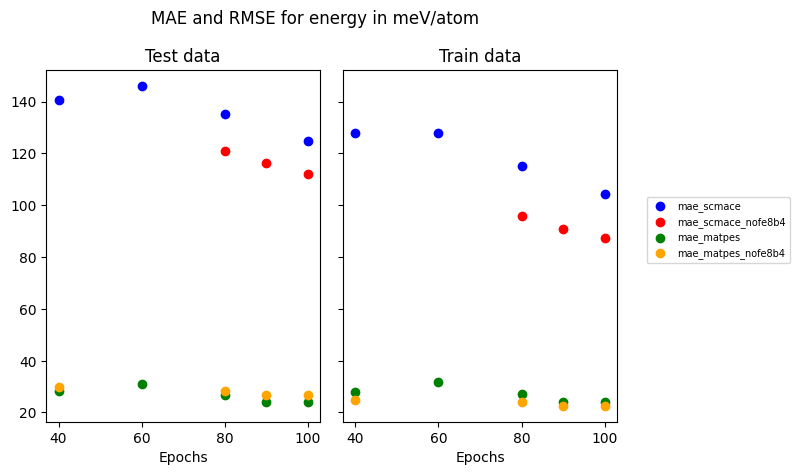

In [98]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

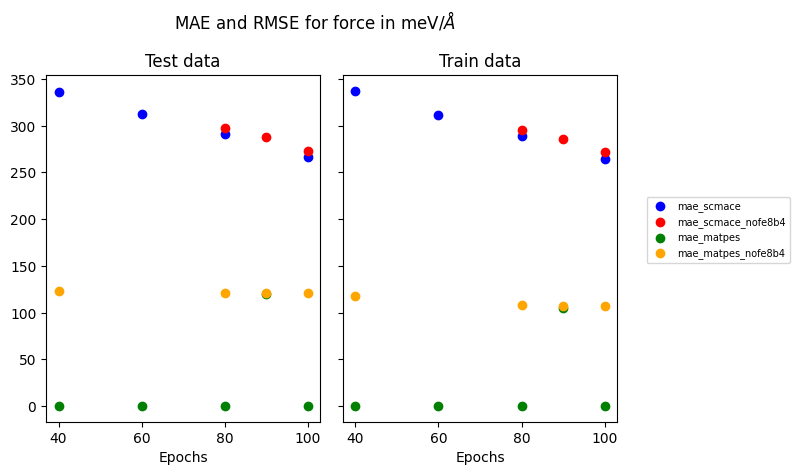

In [99]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

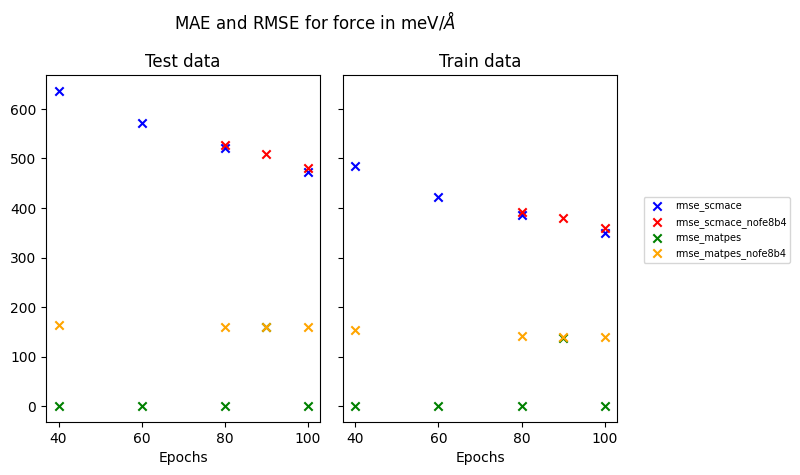

In [100]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['rmse'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

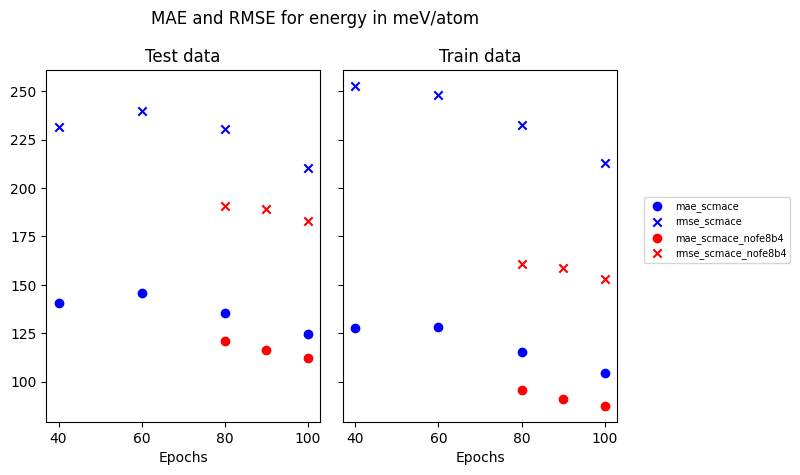

In [101]:
f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

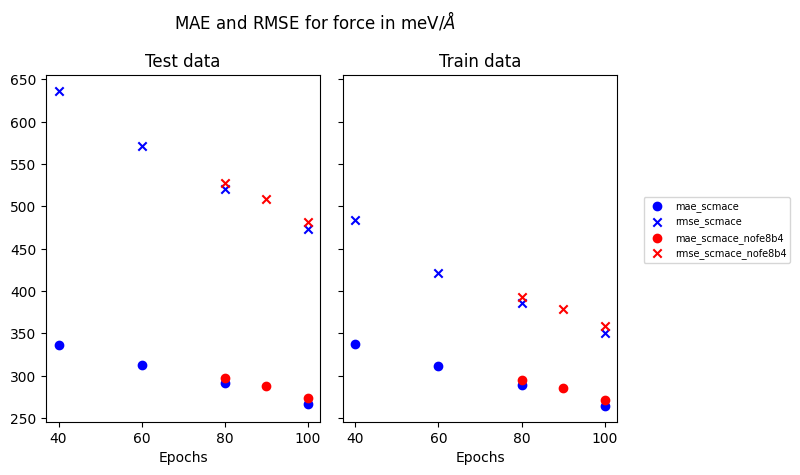

In [102]:
f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

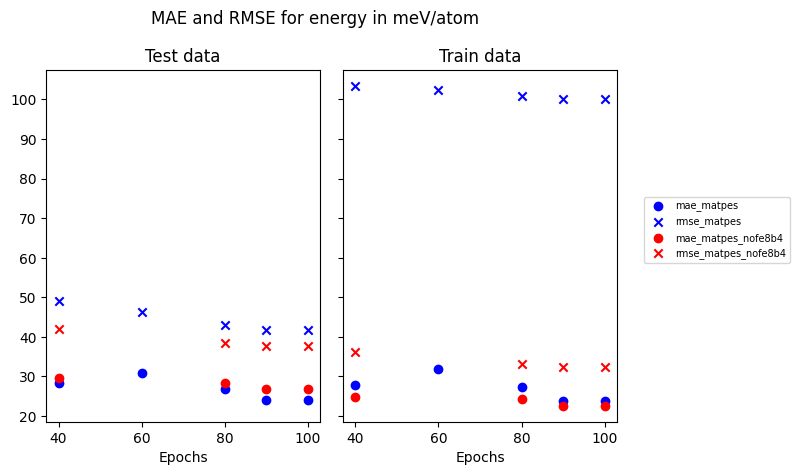

In [103]:
f.plot_global_error([matpes, matpes_nofe8b4], ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

Comparison between fine tuning and freeze tuning

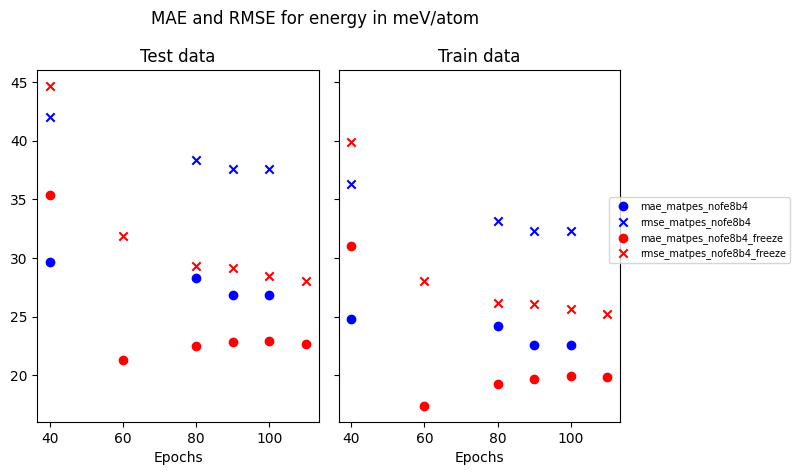

In [104]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'energy')

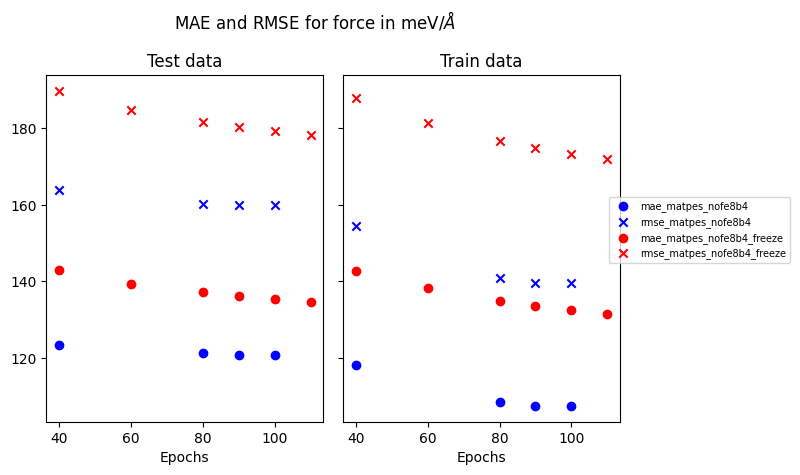

In [105]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'force')

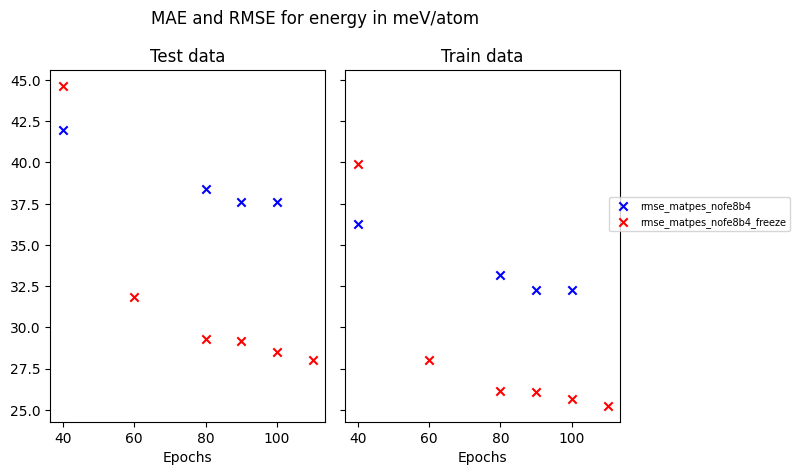

In [106]:
error_type = 'rmse'
value = 'energy'
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze], [error_type], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], value)

In [107]:
#err_comparison = pd.concat([matpes_nofe8b4.query('epochs == 80'),matpes_nofe8b4_freeze.query('epochs == 80')])
err_comparison = pd.concat([matpes_nofe8b4, matpes_nofe8b4_freeze])
#err_comparison = err_comparison.drop(columns=['epochs'])
#err_comparison

In [108]:
#err_comparison.query('error == ["test_energy","train_energy"]')
err_comparison.query('error == "test_energy"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
76,matpes_nofe8b4_freeze,110,test_energy,27.999005,22.687344,0.994573,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_110...
64,matpes_nofe8b4_freeze,100,test_energy,28.495696,22.884726,0.994379,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...
72,matpes_nofe8b4_freeze,90,test_energy,29.152539,22.827509,0.994117,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_90_...
80,matpes_nofe8b4_freeze,80,test_energy,29.275841,22.473856,0.994067,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_80_...
84,matpes_nofe8b4_freeze,60,test_energy,31.870460,21.273370,0.992969,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_60_...
32,matpes_nofe8b4,100,test_energy,37.575629,26.868267,0.990226,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
20,matpes_nofe8b4,90,test_energy,37.575629,26.868267,0.990226,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
8,matpes_nofe8b4,80,test_energy,38.374589,28.255728,0.989806,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
16,matpes_nofe8b4,40,test_energy,41.982686,29.652715,0.987799,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
68,matpes_nofe8b4_freeze,40,test_energy,44.620971,35.353803,0.986217,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_40_...


In [109]:
err_comparison.query('error == "test_force"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
22,matpes_nofe8b4,90,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
34,matpes_nofe8b4,100,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
10,matpes_nofe8b4,80,test_force,160.316953,121.226438,0.996743,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
18,matpes_nofe8b4,40,test_force,163.840934,123.462595,0.996598,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
78,matpes_nofe8b4_freeze,110,test_force,178.133890,134.540010,0.995979,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_110...
66,matpes_nofe8b4_freeze,100,test_force,179.224812,135.350202,0.995929,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...
74,matpes_nofe8b4_freeze,90,test_force,180.297008,136.086905,0.995880,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_90_...
82,matpes_nofe8b4_freeze,80,test_force,181.681786,137.098828,0.995817,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_80_...
86,matpes_nofe8b4_freeze,60,test_force,184.798005,139.316870,0.995672,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_60_...
70,matpes_nofe8b4_freeze,40,test_force,189.690013,142.883930,0.995440,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_40_...


In [110]:
err_comparison.query('error == ["test_force","train_force"]')

,id,epochs,error,rmse,mae,r2,model
10,matpes_nofe8b4,80,test_force,160.316953,121.226438,0.996743,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
11,matpes_nofe8b4,80,train_force,140.868010,108.554588,0.997468,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
18,matpes_nofe8b4,40,test_force,163.840934,123.462595,0.996598,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
19,matpes_nofe8b4,40,train_force,154.385175,118.265340,0.996958,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test
22,matpes_nofe8b4,90,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
23,matpes_nofe8b4,90,train_force,139.439091,107.449706,0.997519,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
34,matpes_nofe8b4,100,test_force,159.889238,120.829418,0.996760,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
35,matpes_nofe8b4,100,train_force,139.439091,107.449706,0.997519,model_rnd_e_matpes_nofe8b4_lr0.0001_100_10_test
66,matpes_nofe8b4_freeze,100,test_force,179.224812,135.350202,0.995929,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...
67,matpes_nofe8b4_freeze,100,train_force,173.328770,132.480723,0.996166,model_rnd_e_matpes_nofe8b4_freeze_lr0.0001_100...


In [111]:
#matpes.query('error == ["test_energy"]').sort_values('epochs', ascending=True)

In [112]:
print(f.min(scmace, 'mae'), f.min(matpes, 'mae'))

                                                model         mae
error                                                            
test_energy   model_rnd_e_scmace_lr0.0001_100_10_test  124.774518
test_force    model_rnd_e_scmace_lr0.0001_100_10_test  266.765534
train_energy  model_rnd_e_scmace_lr0.0001_100_10_test  104.387671
train_force   model_rnd_e_scmace_lr0.0001_100_10_test  264.249749                                                 model        mae
error                                                           
test_energy   model_rnd_e_matpes_lr0.0001_100_10_test  24.019415
test_force    model_rnd_e_matpes_lr0.0001_100_10_test   0.119892
train_energy  model_rnd_e_matpes_lr0.0001_100_10_test  23.863738
train_force   model_rnd_e_matpes_lr0.0001_100_10_test   0.105124


Reading the config errors

In [113]:
df_config =f.read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [114]:
df_config.query('id == "matpes" & epochs == 100')

,id,epochs,config,n_configs,mae,rmse,error,model
62,matpes,100,Fe12B3Si3,48,72.772737,73.184691,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
63,matpes,100,Fe12Si4,12,9.839741,10.007741,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
64,matpes,100,Fe16,11,6.880569,7.642087,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
65,matpes,100,Fe34B10Si10,133,3.642926,4.661568,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
66,matpes,100,Fe8B4,8,115.094036,115.104171,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
67,matpes,100,Fe12B3Si3,132,72.800135,73.055497,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
68,matpes,100,Fe12Si4,39,9.987663,10.192224,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
69,matpes,100,Fe16,40,8.827048,10.186386,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
70,matpes,100,Fe34B10Si10,590,3.656830,4.759407,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
71,matpes,100,Fe8B4,44,173.979772,419.412618,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test


In [115]:
df.query('id == "matpes" & epochs == 100')

,id,epochs,error,rmse,mae,r2,model
28,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
29,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
30,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
31,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test


In [116]:
#voy a generar un dataframe para cada modelo
scmace_config = df_config.query('id == "scmace"')
#matpes_config = df_config.query('id == "matpes"')
matpes_config = df_config.query('id == "matpes" & epochs != [500, 150]')
scmace_nofe8b4_config = df_config.query('id == "scmace_nofe8b4"')
matpes_nofe8b4_config = df_config.query('id == "matpes_nofe8b4"')

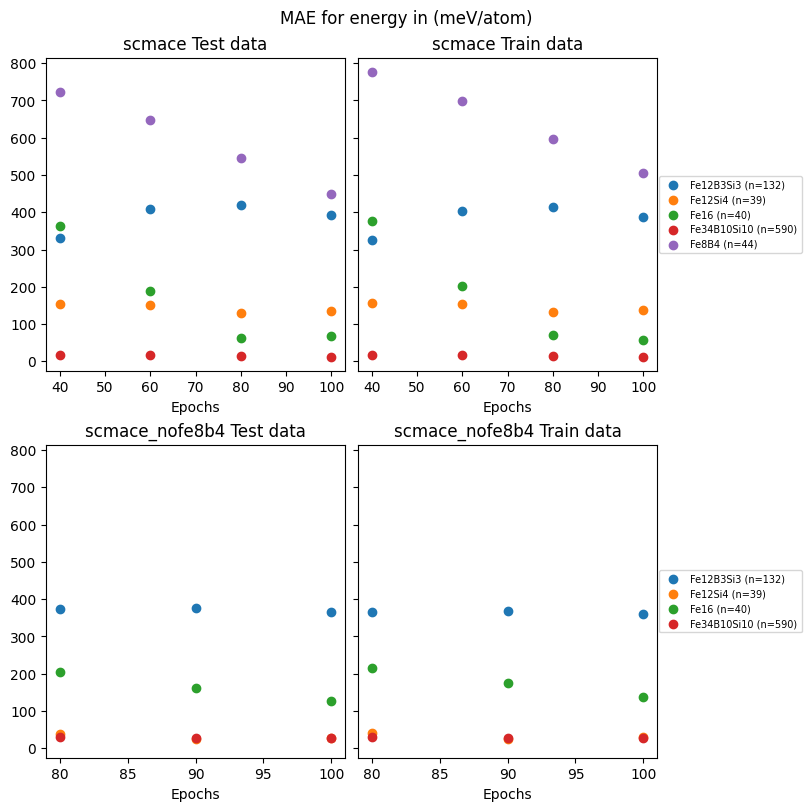

In [117]:
f.plot_config_error([scmace_config, scmace_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')

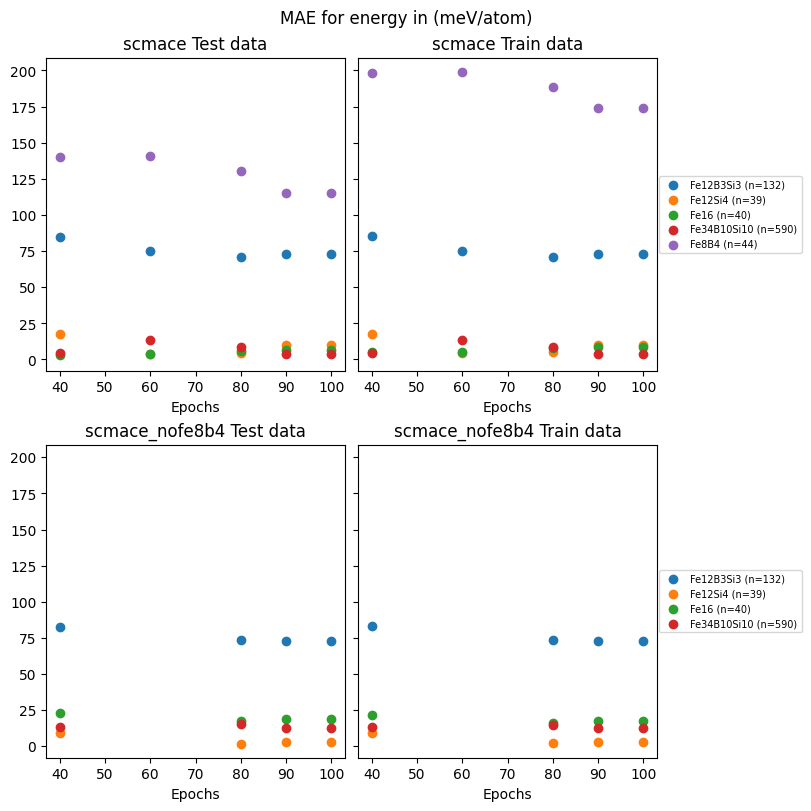

In [118]:
f.plot_config_error([matpes_config, matpes_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')